# Preliminary Analysis

This notebook evaluates whether the selected Gulf Stream drifter data are
sufficient for the proposed trajectory prediction task.

The analysis focuses on:

1. Data quality and SST availability
2. Availability of future observations at candidate forecast horizons
3. Performance of a simple baseline trajectory prediction model

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

processed_dir = Path("../data/processed")

files = {
    "2007-2010": "gulf_stream_q3_2007_2010.parquet",
    "2011-2014": "gulf_stream_q3_2011_2014.parquet",
    "2015-2018": "gulf_stream_q3_2015_2018.parquet",
    "2019-2022": "gulf_stream_q3_2019_2022.parquet"
}

datasets = {
    period: pd.read_parquet(processed_dir / filename)
    for period, filename in files.items()
}

for period, df in datasets.items():
    print(
        period,
        "| rows:", f"{len(df):,}",
        "| trajectories:", df["trajectory_id"].nunique(),
        "| SST missing:", f"{df['sst'].isna().mean():.2%}"
    )

2007-2010 | rows: 616,023 | trajectories: 251 | SST missing: 3.05%
2011-2014 | rows: 640,974 | trajectories: 320 | SST missing: 6.15%
2015-2018 | rows: 587,026 | trajectories: 231 | SST missing: 3.30%
2019-2022 | rows: 638,638 | trajectories: 240 | SST missing: 0.40%


In [12]:
for period, df in datasets.items():
    df["v"] = np.sqrt(df["ve"]**2 + df["vn"]**2)

SST is available for the large majority of observations, although missingness varies across study periods (0.40%–6.15%).

## Forecast Horizon Feasibility

To determine suitable prediction horizons, we examine whether each observation
has an exact future observation from the same trajectory at candidate lead times
of 1, 6, 24, 72 and 168 hours.

Exact timestamp matching is used rather than row shifting to avoid treating
temporal gaps as continuous observations.

In [13]:
horizons = [1, 6, 24, 72, 168]

results = []

for period, df in datasets.items():

    keys = df[["trajectory_id", "time"]].drop_duplicates()

    for h in horizons:

        future = keys.copy()
        future["time"] = future["time"] - pd.Timedelta(hours=h)

        matched = keys.merge(
            future,
            on=["trajectory_id", "time"],
            how="inner"
        )

        results.append({
            "period": period,
            "horizon_hours": h,
            "valid_pairs": len(matched),
            "contributing_drifters": matched["trajectory_id"].nunique(),
            "availability_pct": 100 * len(matched) / len(keys)
        })

horizon_summary = pd.DataFrame(results)

horizon_summary

,period,horizon_hours,valid_pairs,contributing_drifters,availability_pct
0,2007-2010,1,615594,251,99.930360
1,2007-2010,6,613521,251,99.593846
2,2007-2010,24,607149,251,98.559469
3,2007-2010,72,591503,248,96.019629
4,2007-2010,168,560775,247,91.031504
5,2011-2014,1,640438,320,99.916377
6,2011-2014,6,637845,320,99.511837
7,2011-2014,24,629937,320,98.278089
8,2011-2014,72,612320,316,95.529616
9,2011-2014,168,578153,313,90.199134


Exact future observations are available for more than 98% of candidate origins at a 24-hour horizon across all four study periods, with almost all selected drifters contributing valid origin–destination pairs. Availability remains above 90% even at 168 hours. These results indicate that the dataset provides sufficient temporal follow-up for short-term trajectory prediction, supporting the use of 24 hours as the primary forecast horizon.

## Representative Trajectories

A reproducible sample of trajectories is visualised to examine the movement
patterns represented in the study data. Observations outside the Gulf Stream
bounding box are retained because they may form part of the trajectory before
entry or after exit.

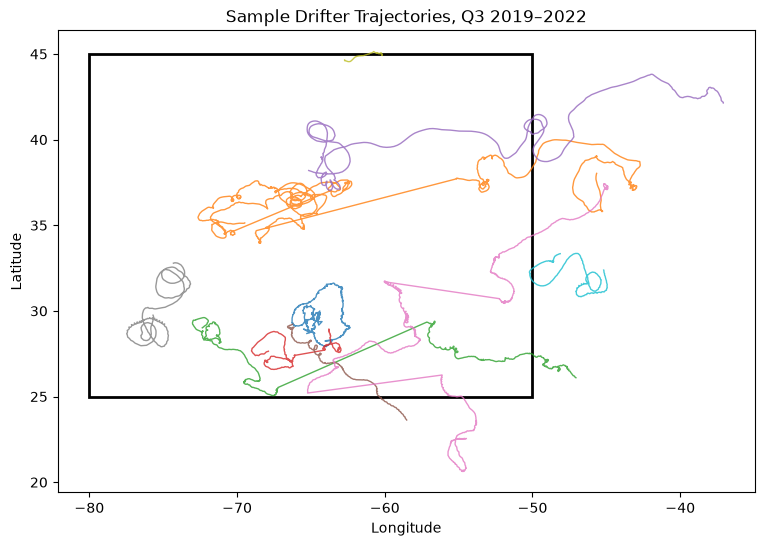

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

df = datasets["2019-2022"]

sample_ids = (
    df["trajectory_id"]
    .drop_duplicates()
    .sample(10, random_state=42)
)

sample = (
    df[df["trajectory_id"].isin(sample_ids)]
    .sort_values(["trajectory_id", "time"])
)

fig, ax = plt.subplots(figsize=(9, 6))

for traj_id, track in sample.groupby("trajectory_id"):
    ax.plot(
        track["lon"],
        track["lat"],
        linewidth=1,
        alpha=0.8
    )

# Gulf Stream study region
ax.add_patch(
    Rectangle(
        (-80, 25),
        30,
        20,
        fill=False,
        linewidth=2
    )
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Sample Drifter Trajectories, Q3 2019–2022")

plt.show()

In [15]:
check_vars = ["lon", "lat", "ve", "vn", "sst"]

for period, df in datasets.items():
    print(f"\n{period}")
    print((df[check_vars].isna().mean() * 100).round(2))


2007-2010
lon    0.00
lat    0.00
ve     0.00
vn     0.00
sst    3.05
dtype: float64

2011-2014
lon    0.00
lat    0.00
ve     0.00
vn     0.00
sst    6.15
dtype: float64

2015-2018
lon    0.0
lat    0.0
ve     0.0
vn     0.0
sst    3.3
dtype: float64

2019-2022
lon    0.0
lat    0.0
ve     0.0
vn     0.0
sst    0.4
dtype: float64


## 24-Hour Constant-Velocity Baseline

As an initial benchmark, we predict each drifter's position 24 hours ahead
by assuming that its current eastward and northward velocities remain constant.

Predicted positions are compared with the observed position exactly 24 hours
later on the same trajectory. Prediction error is measured as geographical
distance in kilometres.

In [16]:
def predict_position(lon, lat, ve, vn, hours=24):
    R = 6371000  # Earth radius in metres
    dt = hours * 3600

    lat_rad = np.radians(lat)

    dlat = (vn * dt / R) * (180 / np.pi)
    dlon = (ve * dt / (R * np.cos(lat_rad))) * (180 / np.pi)

    return lon + dlon, lat + dlat


def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0

    lon1 = np.radians(lon1)
    lat1 = np.radians(lat1)
    lon2 = np.radians(lon2)
    lat2 = np.radians(lat2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = (
        np.sin(dlat / 2)**2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

In [17]:
baseline_results = []

for period, df in datasets.items():

    origins = df[
        ["trajectory_id", "time", "lon", "lat", "ve", "vn"]
    ].copy()

    targets = df[
        ["trajectory_id", "time", "lon", "lat"]
    ].copy()

    targets["time"] = targets["time"] - pd.Timedelta(hours=24)

    pairs = origins.merge(
        targets,
        on=["trajectory_id", "time"],
        how="inner",
        suffixes=("_origin", "_target")
    )

    pairs["pred_lon"], pairs["pred_lat"] = predict_position(
        pairs["lon_origin"],
        pairs["lat_origin"],
        pairs["ve"],
        pairs["vn"],
        hours=24
    )

    pairs["error_km"] = haversine_km(
        pairs["pred_lon"],
        pairs["pred_lat"],
        pairs["lon_target"],
        pairs["lat_target"]
    )

    baseline_results.append({
        "period": period,
        "n_pairs": len(pairs),
        "mean_error_km": pairs["error_km"].mean(),
        "median_error_km": pairs["error_km"].median(),
        "p90_error_km": pairs["error_km"].quantile(0.9)
    })

baseline_summary = pd.DataFrame(baseline_results)

baseline_summary.round(2)

,period,n_pairs,mean_error_km,median_error_km,p90_error_km
0,2007-2010,607149,17.24,13.66,33.34
1,2011-2014,629937,15.86,12.87,29.96
2,2015-2018,577922,15.74,12.45,29.70
3,2019-2022,629689,15.98,12.62,30.09


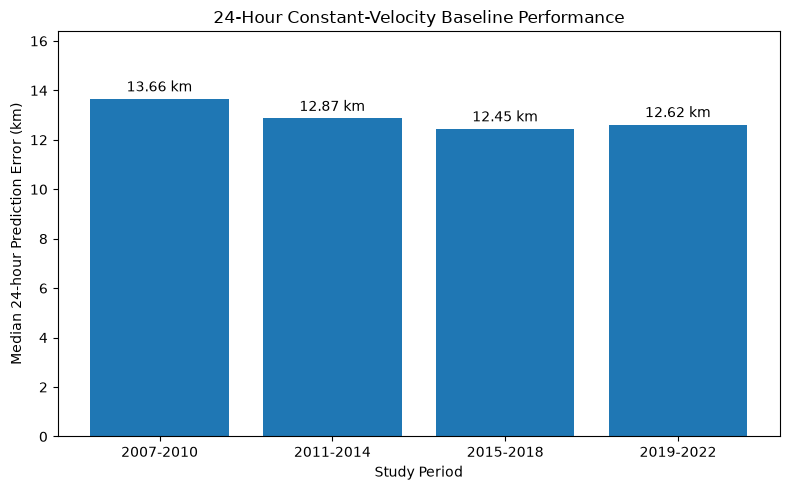

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(baseline_summary))

ax.bar(
    x,
    baseline_summary["median_error_km"]
)

ax.set_xticks(x)
ax.set_xticklabels(baseline_summary["period"])

ax.set_xlabel("Study Period")
ax.set_ylabel("Median 24-hour Prediction Error (km)")
ax.set_title("24-Hour Constant-Velocity Baseline Performance")

ax.bar_label(
    ax.containers[0],
    fmt="%.2f km",
    padding=3
)

ax.set_ylim(0, baseline_summary["median_error_km"].max() * 1.2)

plt.tight_layout()
plt.show()

The 24-hour constant-velocity baseline produced a median geographical
prediction error of approximately 12.5–13.7 km across the four study periods.
Performance was relatively consistent across periods, suggesting that this
provides a stable benchmark for evaluating whether models using recent
trajectory history can improve short-term position forecasts.